# 01 Data Preprocessing

Objective: Handle missing values, scaling, and initial data cleaning.


In [ ]:
import pandas as pd
import numpy as np

In [6]:
file_path = r"C:\Users\David\BTC-trend-prediction\data\raw\coin_Bitcoin.csv"

df = pd.read_csv(file_path, parse_dates=['Date'])

df.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [7]:
df = df.sort_values('Date').reset_index(drop=True)
#sorting dates from oldest to newest, but in this case it already did

In [8]:
df.isnull().sum()
#checking for missing data
#no missing values in this dataset

SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64

In [9]:

df.drop(columns=['SNo','Name','Symbol'], inplace=True)

In [12]:
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

# 02 EDA


Objective: Understand the BTC-USD price dataset, visualize distributions, and identify outliers or seasonal trends.



In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

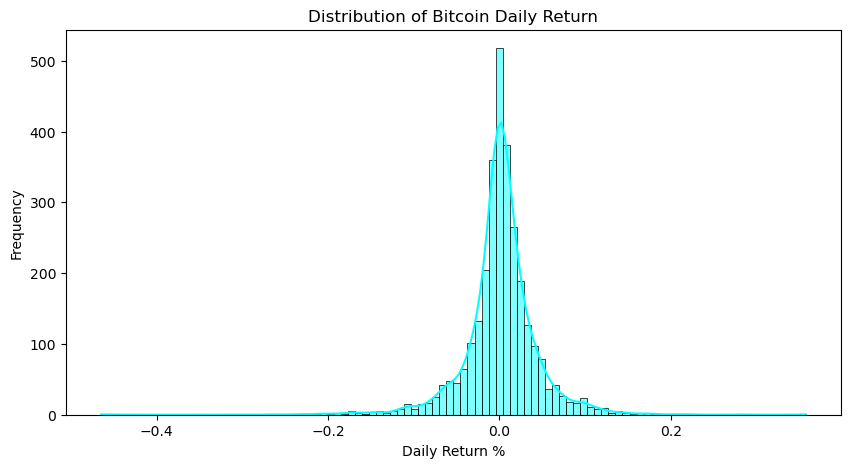

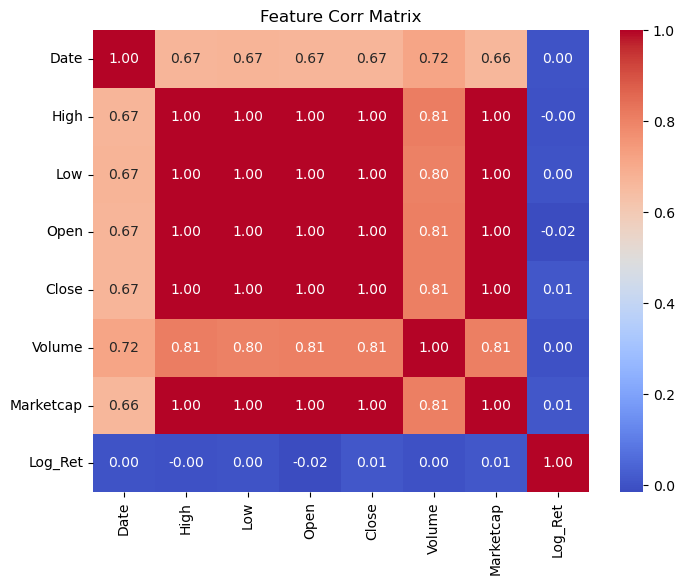

Bitcoin closes green 54.01% of the time


In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df['Log_Ret'], bins=100, kde=True, color='cyan')
plt.title('Distribution of Bitcoin Daily Return')
plt.xlabel('Daily Return %')
plt.ylabel('Frequency')
plt.show

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Corr Matrix')
plt.show()

#calculates how oftern bitcoin goes up
win_rate = (df['Log_Ret'] > 0).mean() * 100
print(f"Bitcoin closes green {win_rate:.2f}% of the time")


In [20]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score

# 03 Feature Engineering

Objective: Create technical indicators (RSI, SMA, MACD) and prepare the feature matrix.